In [1]:
import pandas as pd
DF = pd.read_parquet("processed_data/HI-Small_Trans_TRAIN_processed.parquet")

In [2]:
DF.columns

Index(['Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering', 'TS_Year',
       'TS_Month', 'TS_Day', 'TS_WeekDay', 'TS_Hour', 'TS_Minute',
       'TS_Timestamp', 'Same_Currency', 'FROM', 'TO', 'Same_Bank'],
      dtype='object')

In [3]:
unique_accounts = set(DF[['FROM','TO']].values.ravel())

In [4]:
len(unique_accounts)

513896

In [5]:
mappingDF = pd.DataFrame({"ACC": list(unique_accounts), "IDX":list(range(0,len(unique_accounts)))})
mappingDF.to_parquet("processed_data/mapping_small.prq",index=None)

In [6]:
import pandas as pd
mappingDF = pd.read_parquet("processed_data/mapping_small.prq")
mapping = pd.Series(mappingDF.IDX.values,index=mappingDF.ACC).to_dict()
del mappingDF
del unique_accounts
DF['FROM'] = DF['FROM'].map(mapping)
DF['TO'] = DF['TO'].map(mapping)

In [7]:
from torch import Tensor
from torch_geometric.data import Data
import torch

In [8]:
DF.columns

Index(['Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering', 'TS_Year',
       'TS_Month', 'TS_Day', 'TS_WeekDay', 'TS_Hour', 'TS_Minute',
       'TS_Timestamp', 'Same_Currency', 'FROM', 'TO', 'Same_Bank'],
      dtype='object')

In [9]:
U = torch.LongTensor(DF['FROM'])
V = torch.LongTensor(DF['TO'])
T = torch.LongTensor(DF['TS_Timestamp'])
E_ATTR = torch.Tensor(DF.loc[:, [col for col in DF.columns if col not in ['FROM','TO','TS_Timestamp','Is Laundering']]].values)
#Y = torch.LongTensor(DF['Is Laundering'])

In [10]:
Y = torch.zeros(size=[len(mapping.keys())], dtype=torch.int64)
launderers = pd.unique(DF.loc[DF['Is Laundering'] == 1, ['FROM', 'TO']].values.ravel())
Y[launderers] = 1

In [11]:
pd.Series(Y).value_counts()

0    509433
1      4463
Name: count, dtype: int64

In [12]:
G = Data(edge_index=torch.vstack([U,V]),edge_attr=E_ATTR,y=Y,time=T)

In [13]:
G.num_nodes = len(mapping.keys())

In [14]:
if G.num_nodes is None:
    raise Exception("o no")
train_counts = int(0.9*G.num_nodes)
test_counts = int(G.num_nodes) - train_counts

In [15]:
del DF

In [16]:
G.train_mask = torch.concat((torch.ones(train_counts,dtype=int), torch.zeros(test_counts, dtype=int)),dim=0) # type: ignore
G.test_mask = torch.concat((torch.zeros(train_counts,dtype=int), torch.ones(test_counts, dtype=int)),dim=0) # type: ignore

In [17]:
print("Number of laundering nodes:", Y.sum().item())
print("Indices of laundering nodes:", torch.where(Y == 1)[0])
print("Train laundering nodes:", (Y * G.train_mask).sum().item())
print("Test laundering nodes:", (Y * G.test_mask).sum().item())

Number of laundering nodes: 4463
Indices of laundering nodes: tensor([   136,    224,    442,  ..., 513587, 513675, 513712])
Train laundering nodes: 4022
Test laundering nodes: 441


In [18]:
from torch_geometric.loader import NeighborLoader
import torch.nn.functional as F
G

Data(edge_index=[2, 4062676], edge_attr=[4062676, 13], y=[513896], time=[4062676], num_nodes=513896, train_mask=[513896], test_mask=[513896])

In [19]:
import gc
gc.collect(1)

0

In [20]:
TrainNL = NeighborLoader(
    data=G,
    batch_size=8192,
    num_workers=6,
    num_neighbors=[32, 32],
    temporal_strategy='last',
    persistent_workers=True,
    input_nodes=torch.where(G.train_mask == 1)[0]
)
TestNL = NeighborLoader(
    data=G,
    batch_size=8192,
    num_workers=4,
    num_neighbors=[32, 32],
    temporal_strategy='last',
    persistent_workers=True,
    input_nodes=torch.where(G.test_mask == 1)[0]
)

In [21]:
from tqdm.notebook import tqdm
import torch.nn.functional as F
from GNN_model import AMLGNN
from custom_earlystop import EarlyStopping

In [23]:
model = AMLGNN(in_dim=1,
               edge_attr_dim=13,
               hidden_dim=16)

opt = torch.optim.Adam(model.parameters(), lr=1e-2)
early_stopper = EarlyStopping(patience=5, min_delta=1e-7)
num_epochs = 10


for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(TrainNL, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

    for batch in pbar:
        opt.zero_grad()
        batch.x = torch.ones(batch.n_id.shape[0], 1)
        out = model(batch)
        loss = F.cross_entropy(out[:batch.batch_size], batch.y[:batch.batch_size])
        loss.backward()
        opt.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    avg_train_loss = epoch_loss / len(TrainNL)

    # --- Validation (same loader, no grad) ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in TrainNL:
            batch.x = torch.ones(batch.n_id.shape[0], 1)
            out = model(batch)
            loss = F.cross_entropy(out[:batch.batch_size], batch.y[:batch.batch_size])
            val_loss += loss.item()
    avg_val_loss = val_loss / len(TrainNL)

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.7f} | Val Loss: {avg_val_loss:.7f}")

    # --- Early stopping check ---
    early_stopper.step(avg_val_loss)
    if early_stopper.should_stop:
        print("Early stopping triggered")
        break

Epoch 1/10:   0%|          | 0/57 [00:00<?, ?batch/s]

Epoch 1 | Train Loss: 2659.8425038 | Val Loss: 450.6935827


Epoch 2/10:   0%|          | 0/57 [00:00<?, ?batch/s]

Epoch 2 | Train Loss: 271.4748248 | Val Loss: 97.8533929


Epoch 3/10:   0%|          | 0/57 [00:00<?, ?batch/s]

...

Epoch 8 | Train Loss: 88.0187533 | Val Loss: 49.4402681


Epoch 9/10:   0%|          | 0/57 [00:00<?, ?batch/s]

Epoch 9 | Train Loss: 21.4144355 | Val Loss: 15.0644705


Epoch 10/10:   0%|          | 0/57 [00:00<?, ?batch/s]

Epoch 10 | Train Loss: 14.7820606 | Val Loss: 5.7624790


In [24]:
import torch
from datetime import datetime
# If you also want optimizer state (for resuming training):
torch.save({
    "epoch": epoch,
    "model_state": model.state_dict(),
    "optimizer_state": opt.state_dict(),
    "time": str(datetime.now())
}, "aml_gnn_checkpoint.pth")

In [25]:
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Put model in eval mode
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    # for batch in TrainNL:
    #     batch.x = torch.ones(batch.n_id.shape[0], 1)
    #     out = model(batch)  # logits, shape [batch_size, num_classes]
    #     preds = out.argmax(dim=1)
    #     all_preds.append(preds.cpu())
    #     all_targets.append(batch.y)
    for batch in TestNL:
        batch.x = torch.ones(batch.n_id.shape[0], 1)
        out = model(batch)
        preds = out.argmax(dim=1)
        # Only keep predictions for the target nodes (input nodes of this batch)
        # The first batch.batch_size nodes are the input (target) nodes
        all_preds.append(preds[:batch.batch_size].cpu())
        all_targets.append(batch.y[:batch.batch_size])
# Concatenate all batches
all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()



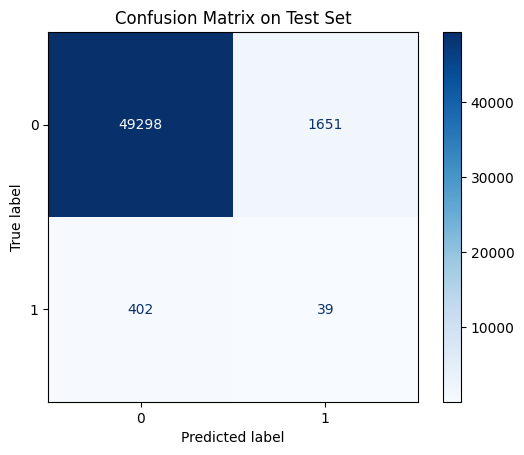

In [26]:
# Compute confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.show()


In [ ]:
G.num_nodes

513896

In [ ]:
batch

Data(edge_index=[2, 37626], edge_attr=[37626, 13], y=[7525], time=[37626], num_nodes=7525, train_mask=[7525], test_mask=[7525], n_id=[7525], e_id=[37626], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[2238], batch_size=2238, x=[7525, 1])

In [ ]:
batch.n_id.shape

torch.Size([7525])

In [ ]:
batch.y.shape

torch.Size([7525])

In [ ]:
all_preds, all_targets

(array([0, 0, 0, ..., 0, 0, 0], shape=(51390,)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(51390,)))

In [ ]:
test_counts

51390

In [ ]:
batch.input_id.shape

torch.Size([2238])

In [ ]:
pd.Series(all_targets).value_counts()

0    50952
1      438
Name: count, dtype: int64